# Lab P3: Build a Classifier (The Baby Discriminator)

**Goal:** Build a binary classifier from scratch using Sigmoid and BCE loss — the exact building blocks of a GAN's Discriminator.

**What you'll learn:**
- Sigmoid: squash any number to a probability (0-1)
- BCE loss: the right loss function for "yes or no" questions
- Why BCE beats MSE for classification
- Train a classifier that says "positive" or "negative"
- Connect this directly to how a Discriminator works

**The punchline:** This classifier IS a Discriminator. Just replace "positive/negative" with "real/fake".

**Time:** ~45 minutes

---

## Part 1: The Classification Problem

Until now: predict a **number** (regression).  
Now: predict a **category** — yes or no, real or fake, positive or negative.

Our task: given a number, classify it as **positive (1)** or **negative (0)**.

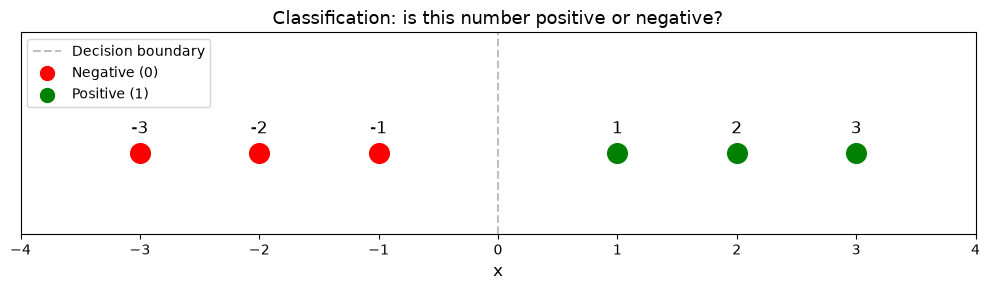

The output should be a PROBABILITY between 0 and 1.
But y = wx + b can output ANY number. We need to squash it.


In [1]:
import matplotlib.pyplot as plt
import math

# Training data
X = [-3, -2, -1, 1, 2, 3]
Y = [ 0,  0,  0, 1, 1, 1]   # 0 = negative, 1 = positive

fig, ax = plt.subplots(figsize=(10, 3))
for x, y in zip(X, Y):
    color = 'red' if y == 0 else 'green'
    label_text = 'Negative (0)' if y == 0 else 'Positive (1)'
    ax.scatter(x, 0, color=color, s=200, zorder=5)
    ax.annotate(f'{x}', (x, 0.05), ha='center', fontsize=12)

ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
ax.scatter([], [], color='red', s=100, label='Negative (0)')
ax.scatter([], [], color='green', s=100, label='Positive (1)')
ax.set_xlim(-4, 4)
ax.set_ylim(-0.2, 0.3)
ax.set_yticks([])
ax.set_xlabel('x', fontsize=12)
ax.set_title('Classification: is this number positive or negative?', fontsize=13)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("The output should be a PROBABILITY between 0 and 1.")
print("But y = wx + b can output ANY number. We need to squash it.")

---
## Part 2: Sigmoid — Squash to Probability

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

No matter what z is, sigmoid outputs a number between 0 and 1.

| z | sigmoid(z) | Meaning |
|---:|---:|---|
| -10 | 0.00005 | Very confident: negative |
| -2 | 0.12 | Probably negative |
| 0 | 0.50 | Unsure (50/50) |
| 2 | 0.88 | Probably positive |
| 10 | 0.99995 | Very confident: positive |

In [2]:
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

# Test sigmoid
print("Sigmoid values:")
print("-" * 45)
for z in [-10, -5, -2, -1, 0, 1, 2, 5, 10]:
    p = sigmoid(z)
    bar = '#' * int(p * 40)
    print(f"  sigmoid({z:+3d}) = {p:.5f}  {bar}")

Sigmoid values:
---------------------------------------------
  sigmoid(-10) = 0.00005  
  sigmoid( -5) = 0.00669  
  sigmoid( -2) = 0.11920  ####
  sigmoid( -1) = 0.26894  ##########
  sigmoid( +0) = 0.50000  ####################
  sigmoid( +1) = 0.73106  #############################
  sigmoid( +2) = 0.88080  ###################################
  sigmoid( +5) = 0.99331  #######################################
  sigmoid(+10) = 0.99995  #######################################


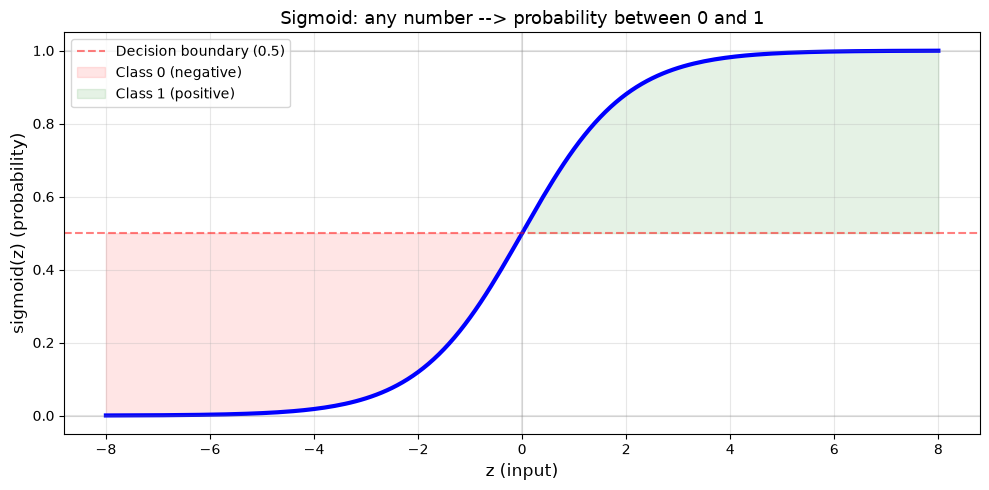

In [3]:
# Visualize sigmoid
z_vals = [z/10 for z in range(-80, 81)]
s_vals = [sigmoid(z) for z in z_vals]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z_vals, s_vals, 'b-', linewidth=3)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
ax.axhline(y=0, color='gray', alpha=0.2)
ax.axhline(y=1, color='gray', alpha=0.2)
ax.axvline(x=0, color='gray', alpha=0.2)

# Annotate regions
ax.fill_between(z_vals, s_vals, 0.5, where=[s < 0.5 for s in s_vals],
                alpha=0.1, color='red', label='Class 0 (negative)')
ax.fill_between(z_vals, 0.5, s_vals, where=[s > 0.5 for s in s_vals],
                alpha=0.1, color='green', label='Class 1 (positive)')

ax.set_xlabel('z (input)', fontsize=12)
ax.set_ylabel('sigmoid(z) (probability)', fontsize=12)
ax.set_title('Sigmoid: any number --> probability between 0 and 1', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### The neuron + sigmoid = classifier

```
x  -->  [w * x + b]  -->  z  -->  [sigmoid]  -->  p (probability)
         neuron            raw        squash        0 to 1
```

In [4]:
# Test the full pipeline
w = 0.5
b = 0.0

print(f"Classifier with w={w}, b={b}:")
print("-" * 55)
for x, y in zip(X, Y):
    z = w * x + b
    p = sigmoid(z)
    predicted_class = 1 if p > 0.5 else 0
    correct = "yes" if predicted_class == y else "NO"
    print(f"  x={x:+d}: z={z:+.1f}, p={p:.4f}, predict={predicted_class}, actual={y}  [{correct}]")

print(f"\nNot bad even with untrained weights!")
print(f"But we want higher confidence. The loss function will help.")

Classifier with w=0.5, b=0.0:
-------------------------------------------------------
  x=-3: z=-1.5, p=0.1824, predict=0, actual=0  [yes]
  x=-2: z=-1.0, p=0.2689, predict=0, actual=0  [yes]
  x=-1: z=-0.5, p=0.3775, predict=0, actual=0  [yes]
  x=+1: z=+0.5, p=0.6225, predict=1, actual=1  [yes]
  x=+2: z=+1.0, p=0.7311, predict=1, actual=1  [yes]
  x=+3: z=+1.5, p=0.8176, predict=1, actual=1  [yes]

Not bad even with untrained weights!
But we want higher confidence. The loss function will help.


---
## Part 3: BCE Loss — The Right Loss for Classification

MSE works for regression. For classification, we use **Binary Cross-Entropy (BCE)**:

$$BCE = -[y \cdot \log(p) + (1-y) \cdot \log(1-p)]$$

Two cases:
- When target = 1: `BCE = -log(p)` — push p toward 1
- When target = 0: `BCE = -log(1-p)` — push p toward 0

BCE punishes confident wrong answers **exponentially** — much harsher than MSE.

In [5]:
def bce_loss(p, target):
    """Binary Cross-Entropy for a single prediction."""
    eps = 1e-8  # tiny number to avoid log(0)
    if target == 1:
        return -math.log(p + eps)
    else:
        return -math.log(1 - p + eps)

# See how BCE loss behaves
print("When target = 1 (should predict high p):")
print("-" * 50)
for p in [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    loss = bce_loss(p, 1)
    bar = '#' * int(min(loss * 5, 50))
    print(f"  p={p:.2f}: BCE={loss:.4f}  {bar}")

print(f"\nWhen target = 0 (should predict low p):")
print("-" * 50)
for p in [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    loss = bce_loss(p, 0)
    bar = '#' * int(min(loss * 5, 50))
    print(f"  p={p:.2f}: BCE={loss:.4f}  {bar}")

When target = 1 (should predict high p):
--------------------------------------------------
  p=0.01: BCE=4.6052  #######################
  p=0.10: BCE=2.3026  ###########
  p=0.30: BCE=1.2040  ######
  p=0.50: BCE=0.6931  ###
  p=0.70: BCE=0.3567  #
  p=0.90: BCE=0.1054  
  p=0.99: BCE=0.0101  

When target = 0 (should predict low p):
--------------------------------------------------
  p=0.01: BCE=0.0101  
  p=0.10: BCE=0.1054  
  p=0.30: BCE=0.3567  #
  p=0.50: BCE=0.6931  ###
  p=0.70: BCE=1.2040  ######
  p=0.90: BCE=2.3026  ###########
  p=0.99: BCE=4.6052  #######################


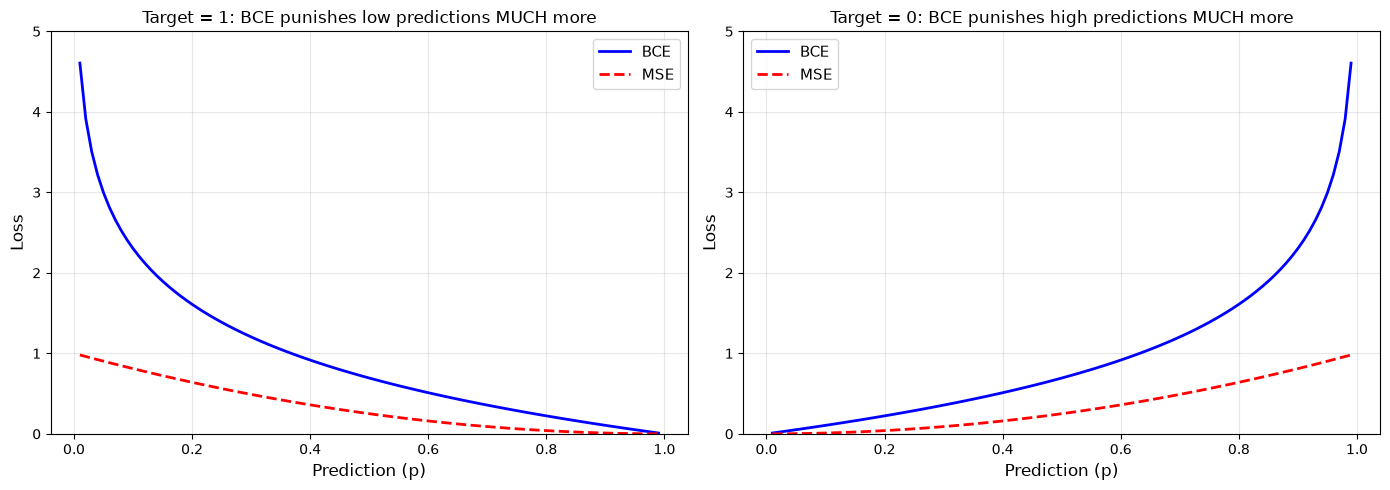

BCE shoots up exponentially for wrong answers.
MSE grows gently. BCE creates stronger gradients = faster learning.


In [6]:
# Visualize: BCE vs MSE
p_vals = [p/100 for p in range(1, 100)]

bce_target1 = [-math.log(p) for p in p_vals]
mse_target1 = [(p - 1)**2 for p in p_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(p_vals, bce_target1, 'b-', linewidth=2, label='BCE')
axes[0].plot(p_vals, mse_target1, 'r--', linewidth=2, label='MSE')
axes[0].set_xlabel('Prediction (p)', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Target = 1: BCE punishes low predictions MUCH more', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 5)
axes[0].grid(True, alpha=0.3)

bce_target0 = [-math.log(1-p) for p in p_vals]
mse_target0 = [p**2 for p in p_vals]

axes[1].plot(p_vals, bce_target0, 'b-', linewidth=2, label='BCE')
axes[1].plot(p_vals, mse_target0, 'r--', linewidth=2, label='MSE')
axes[1].set_xlabel('Prediction (p)', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Target = 0: BCE punishes high predictions MUCH more', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].set_ylim(0, 5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("BCE shoots up exponentially for wrong answers.")
print("MSE grows gently. BCE creates stronger gradients = faster learning.")

---
## Part 4: The Beautiful Gradient

For Sigmoid + BCE, the gradient simplifies to something beautiful:

$$\text{gradient} = p - y$$

That's it! The gradient is just: **prediction minus target**.

| Situation | p | y | gradient | Action |
|---|---|---|---|---|
| Correct & confident | 0.95 | 1 | -0.05 | Tiny nudge (already good) |
| Wrong & confident | 0.95 | 0 | +0.95 | **Big correction** |
| Unsure | 0.50 | 1 | -0.50 | Medium push toward 1 |

In [7]:
# Demonstrate the gradient
print("Sigmoid+BCE gradient = p - y:")
print("=" * 55)

cases = [
    (0.95, 1, "Correct, confident"),
    (0.50, 1, "Unsure"),
    (0.10, 1, "Wrong!"),
    (0.05, 0, "Correct, confident"),
    (0.50, 0, "Unsure"),
    (0.90, 0, "Wrong!"),
]

for p, y, desc in cases:
    grad = p - y
    action = "push down" if grad > 0 else "push up"
    print(f"  p={p:.2f}, y={y}: grad={grad:+.2f}  ({action:10s})  [{desc}]")

Sigmoid+BCE gradient = p - y:
  p=0.95, y=1: grad=-0.05  (push up   )  [Correct, confident]
  p=0.50, y=1: grad=-0.50  (push up   )  [Unsure]
  p=0.10, y=1: grad=-0.90  (push up   )  [Wrong!]
  p=0.05, y=0: grad=+0.05  (push down )  [Correct, confident]
  p=0.50, y=0: grad=+0.50  (push down )  [Unsure]
  p=0.90, y=0: grad=+0.90  (push down )  [Wrong!]


---
## Part 5: Train the Classifier

In [8]:
# Train a single-neuron classifier with Sigmoid + BCE
w = 0.5
b = 0.0
lr = 0.1

loss_history = []
w_history = [w]
b_history = [b]

print("Training the classifier:")
print("=" * 60)

for epoch in range(1, 201):
    epoch_loss = 0

    for x, y in zip(X, Y):
        # Forward pass
        z = w * x + b
        p = sigmoid(z)

        # BCE loss
        loss = bce_loss(p, y)
        epoch_loss += loss

        # Gradient (the beautiful formula: p - y)
        grad = p - y

        # Update weights
        w -= lr * grad * x     # gradient w.r.t. weight includes x
        b -= lr * grad         # gradient w.r.t. bias is just grad

    avg_loss = epoch_loss / len(X)
    loss_history.append(avg_loss)
    w_history.append(w)
    b_history.append(b)

    if epoch in [1, 5, 10, 25, 50, 100, 200]:
        print(f"  Epoch {epoch:3d}: loss={avg_loss:.6f}  w={w:.4f}  b={b:.4f}")

print(f"\nFinal: w={w:.4f}, b={b:.4f}")

Training the classifier:
  Epoch   1: loss=0.284362  w=0.7488  b=-0.0089
  Epoch   5: loss=0.125495  w=1.2636  b=-0.0150
  Epoch  10: loss=0.080571  w=1.6055  b=-0.0143
  Epoch  25: loss=0.042122  w=2.1639  b=-0.0107
  Epoch  50: loss=0.024558  w=2.6625  b=-0.0074
  Epoch 100: loss=0.013734  w=3.2191  b=-0.0046
  Epoch 200: loss=0.007409  w=3.8223  b=-0.0027

Final: w=3.8223, b=-0.0027


In [9]:
# Test the trained classifier
print("Trained classifier predictions:")
print("=" * 55)

for x, y in zip(X, Y):
    z = w * x + b
    p = sigmoid(z)
    predicted = 1 if p > 0.5 else 0
    confidence = p if predicted == 1 else 1 - p
    correct = "correct" if predicted == y else "WRONG"
    print(f"  x={x:+d}: p={p:.6f}  predict={predicted}  actual={y}  "
          f"({confidence:.1%} confident)  [{correct}]")

accuracy = sum(1 for x, y in zip(X, Y)
               if (1 if sigmoid(w*x + b) > 0.5 else 0) == y) / len(X)
print(f"\nAccuracy: {accuracy:.0%}")

Trained classifier predictions:
  x=-3: p=0.000010  predict=0  actual=0  (100.0% confident)  [correct]
  x=-2: p=0.000477  predict=0  actual=0  (100.0% confident)  [correct]
  x=-1: p=0.021353  predict=0  actual=0  (97.9% confident)  [correct]
  x=+1: p=0.978535  predict=1  actual=1  (97.9% confident)  [correct]
  x=+2: p=0.999520  predict=1  actual=1  (100.0% confident)  [correct]
  x=+3: p=0.999990  predict=1  actual=1  (100.0% confident)  [correct]

Accuracy: 100%


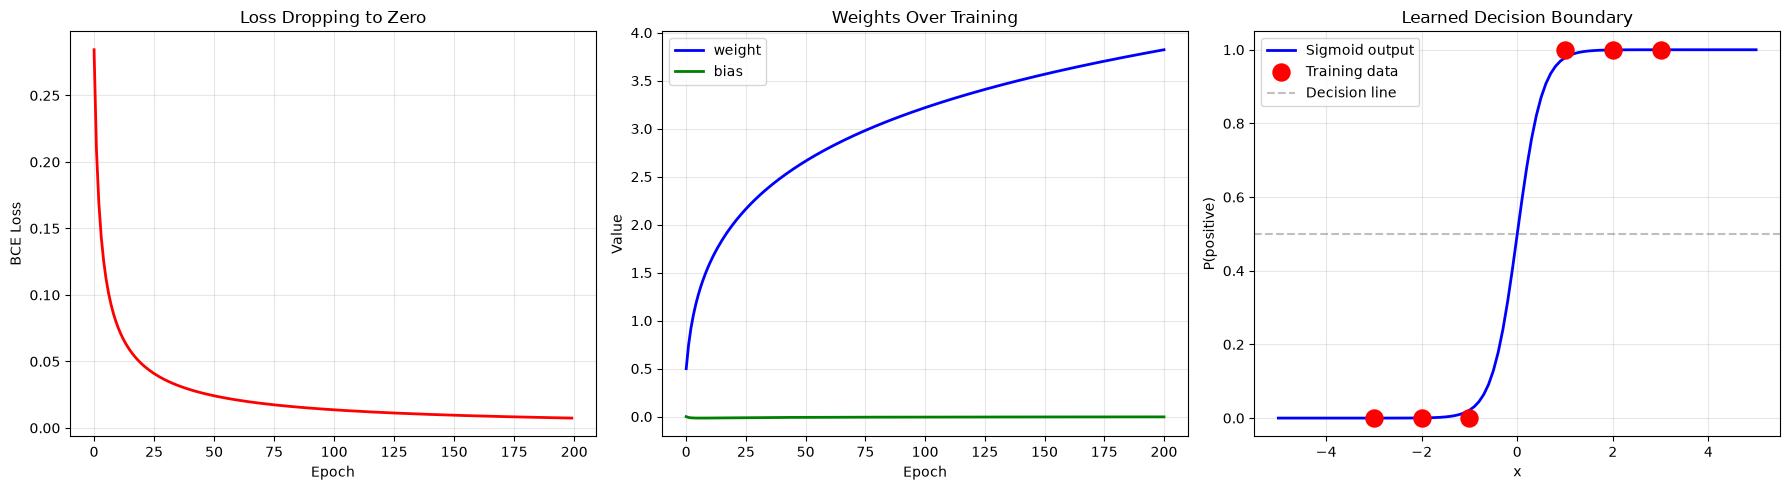

In [10]:
# Visualize training
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(loss_history, 'r-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Loss Dropping to Zero')
axes[0].grid(True, alpha=0.3)

# Weight evolution
axes[1].plot(w_history, 'b-', linewidth=2, label='weight')
axes[1].plot(b_history, 'g-', linewidth=2, label='bias')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Value')
axes[1].set_title('Weights Over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Decision boundary (sigmoid curve)
x_range = [x/10 for x in range(-50, 51)]
p_range = [sigmoid(w * x + b) for x in x_range]

axes[2].plot(x_range, p_range, 'b-', linewidth=2, label='Sigmoid output')
axes[2].scatter(X, Y, color='red', s=150, zorder=5, label='Training data')
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Decision line')
axes[2].set_xlabel('x')
axes[2].set_ylabel('P(positive)')
axes[2].set_title('Learned Decision Boundary')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 6: What the Weight and Bias Control

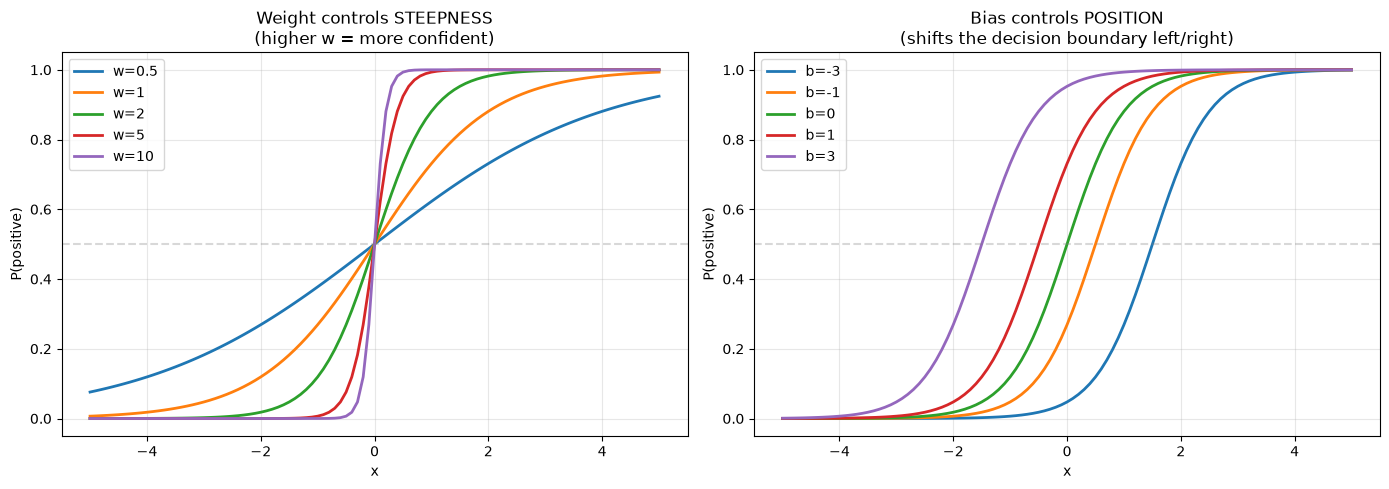

In [11]:
# Show how w controls steepness and b controls position
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_range = [x/10 for x in range(-50, 51)]

# Different weights (steepness)
for w_test in [0.5, 1, 2, 5, 10]:
    p_test = [sigmoid(w_test * x) for x in x_range]
    axes[0].plot(x_range, p_test, linewidth=2, label=f'w={w_test}')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
axes[0].set_title('Weight controls STEEPNESS\n(higher w = more confident)', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('P(positive)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Different biases (shift)
for b_test in [-3, -1, 0, 1, 3]:
    p_test = [sigmoid(2 * x + b_test) for x in x_range]
    axes[1].plot(x_range, p_test, linewidth=2, label=f'b={b_test}')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
axes[1].set_title('Bias controls POSITION\n(shifts the decision boundary left/right)', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_ylabel('P(positive)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 7: From Classifier to Discriminator

This is the key connection to GANs.

| This classifier | GAN Discriminator |
|---|---|
| Input: a number | Input: an **image** (784 pixels) |
| Output: positive or negative? | Output: **real or fake?** |
| 1 neuron + Sigmoid | Many layers + Sigmoid |
| BCE loss | BCE loss (same!) |
| Gradient: p - y | Gradient: p - y (same!) |
| Target: 0 or 1 | Target: 0 (fake) or 1 (real) |

In [12]:
# Simulate the Discriminator's job
print("Think of this classifier as a baby Discriminator:")
print("=" * 55)

# In a GAN:
# - Real images get label 1
# - Fake images (from Generator) get label 0
# - Discriminator tries to tell them apart

# Simulate with our classifier
real_data = [1, 2, 3]        # "real" examples
fake_data = [-3, -2, -1]     # "fake" examples

print("\nReal data (should output ~1.0):")
for x in real_data:
    p = sigmoid(w * x + b)
    print(f"  D({x}) = {p:.4f}  {'correct' if p > 0.5 else 'WRONG'}")

print("\nFake data (should output ~0.0):")
for x in fake_data:
    p = sigmoid(w * x + b)
    print(f"  D({x}) = {p:.4f}  {'correct' if p < 0.5 else 'WRONG'}")

print("\nThis is EXACTLY what a Discriminator does in a GAN!")
print("The only difference: real GANs use images instead of numbers.")

Think of this classifier as a baby Discriminator:

Real data (should output ~1.0):
  D(1) = 0.9785  correct
  D(2) = 0.9995  correct
  D(3) = 1.0000  correct

Fake data (should output ~0.0):
  D(-3) = 0.0000  correct
  D(-2) = 0.0005  correct
  D(-1) = 0.0214  correct

This is EXACTLY what a Discriminator does in a GAN!
The only difference: real GANs use images instead of numbers.


---
## Part 8: Experiments

### Experiment 1: Shifted decision boundary

What if positive = numbers > 2 (not > 0)?

Learned: w=2.8546, b=-6.7996
Decision boundary at x = 2.38 (should be ~2.5)



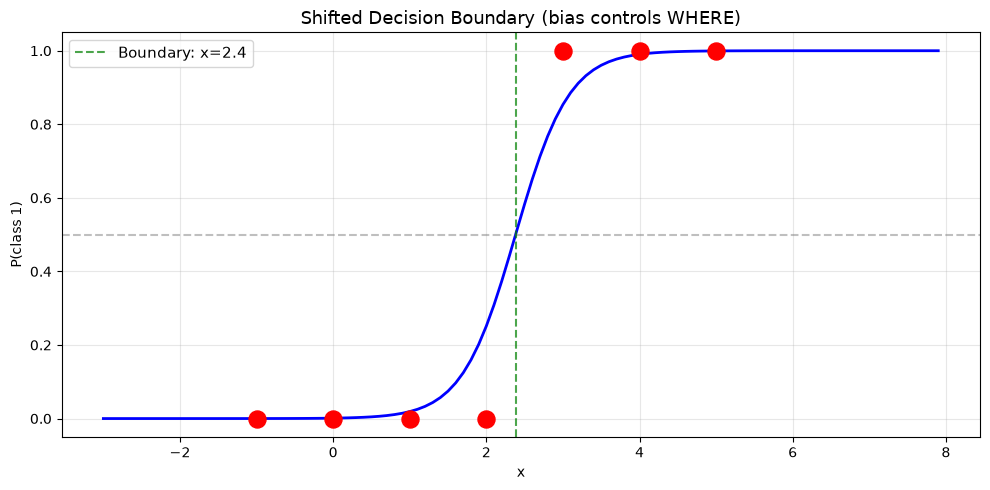

The bias shifted the boundary from 0 to ~2.4!


In [13]:
# New task: classify as > 2 or <= 2
X_shifted = [-1, 0, 1, 2, 3, 4, 5]
Y_shifted = [ 0, 0, 0, 0, 1, 1, 1]   # boundary at 2

w_s = 0.5
b_s = 0.0
lr = 0.1

for epoch in range(300):
    for x, y in zip(X_shifted, Y_shifted):
        z = w_s * x + b_s
        p = sigmoid(z)
        grad = p - y
        w_s -= lr * grad * x
        b_s -= lr * grad

print(f"Learned: w={w_s:.4f}, b={b_s:.4f}")
print(f"Decision boundary at x = {-b_s/w_s:.2f} (should be ~2.5)")
print()

# Visualize
x_range = [x/10 for x in range(-30, 80)]
p_range = [sigmoid(w_s * x + b_s) for x in x_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_range, p_range, 'b-', linewidth=2)
ax.scatter(X_shifted, Y_shifted, color='red', s=150, zorder=5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=-b_s/w_s, color='green', linestyle='--', alpha=0.7,
           label=f'Boundary: x={-b_s/w_s:.1f}')
ax.set_xlabel('x')
ax.set_ylabel('P(class 1)')
ax.set_title('Shifted Decision Boundary (bias controls WHERE)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The bias shifted the boundary from 0 to ~{-b_s/w_s:.1f}!")

### Experiment 2: Confidence over training

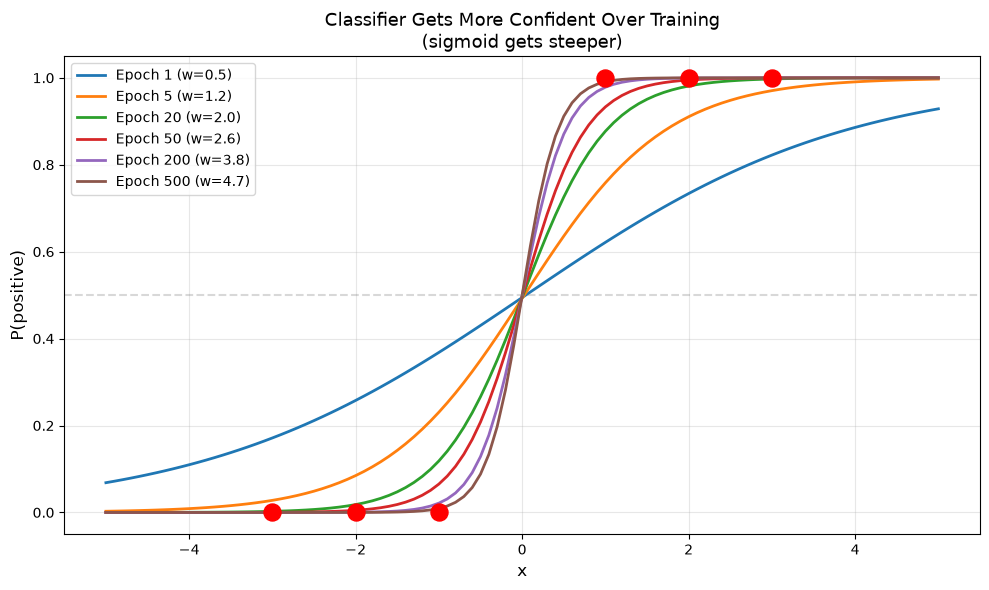

Early: sigmoid is gentle (uncertain predictions).
Late:  sigmoid is steep (confident predictions).
The weight controls confidence. Larger w = steeper sigmoid = more confident.


In [14]:
# Track how confident the classifier becomes over training
w_c = 0.1
b_c = 0.0
lr = 0.1

snapshots = {}

for epoch in range(1, 501):
    for x, y in zip(X, Y):
        z = w_c * x + b_c
        p = sigmoid(z)
        grad = p - y
        w_c -= lr * grad * x
        b_c -= lr * grad

    if epoch in [1, 5, 20, 50, 200, 500]:
        snapshots[epoch] = (w_c, b_c)

# Plot sigmoid curves at different training stages
fig, ax = plt.subplots(figsize=(10, 6))
x_range = [x/10 for x in range(-50, 51)]

for epoch, (w_snap, b_snap) in snapshots.items():
    p_snap = [sigmoid(w_snap * x + b_snap) for x in x_range]
    ax.plot(x_range, p_snap, linewidth=2, label=f'Epoch {epoch} (w={w_snap:.1f})')

ax.scatter(X, Y, color='red', s=150, zorder=5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('P(positive)', fontsize=12)
ax.set_title('Classifier Gets More Confident Over Training\n(sigmoid gets steeper)',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Early: sigmoid is gentle (uncertain predictions).")
print("Late:  sigmoid is steep (confident predictions).")
print("The weight controls confidence. Larger w = steeper sigmoid = more confident.")

---
## Part 9: Summary — The Road to GANs

| Lab | What you built | GAN connection |
|---|---|---|
| **P1** | Learning neuron | Every weight in G and D learns this way |
| **P2** | Hidden layer + backprop | G and D are multi-layer networks |
| **P3** | Binary classifier | **This IS the Discriminator** |

| Component | What you learned | What it becomes |
|---|---|---|
| Sigmoid | Squash to probability | D's output layer |
| BCE Loss | Penalize wrong classifications | GAN's loss function |
| Gradient: p-y | Simple, effective | How D learns |
| Weight → confidence | Larger w = more confident | D gets better at judging |

**The full GAN picture:**
```
Generator:      noise --> [network] --> fake image
Discriminator:  image --> [network + Sigmoid] --> P(real)    <-- THIS IS WHAT YOU JUST BUILT
BCE Loss:       pushes D toward correct classifications
Training:       D improves at judging, G improves at fooling
```

**Next lab:** Lab 0 translates everything you built by hand into PyTorch — same concepts, less code.